In [1]:
import pandas as pd

df = pd.read_csv("https://nmimoto.github.io/datasets/pigs.csv")
df["unique_id"] = "Lake Huron"
df.rename(columns={"Month": "ds", "Pigs": "y"}, inplace=True)
df["ds"] = pd.to_datetime(df["ds"], format="%Y-%m") + pd.offsets.MonthEnd(0)
df = df[["unique_id", "ds", "y"]]
df

,unique_id,ds,y
0,Lake Huron,1980-01-31,76378
1,Lake Huron,1980-02-29,71947
2,Lake Huron,1980-03-31,33873
3,Lake Huron,1980-04-30,96428
4,Lake Huron,1980-05-31,105084
...,...,...,...
183,Lake Huron,1995-04-30,84307
184,Lake Huron,1995-05-31,114896
185,Lake Huron,1995-06-30,106749
186,Lake Huron,1995-07-31,87892


In [2]:
from statsforecast import StatsForecast
from statsforecast.models import (
    AutoTheta,
    AutoETS,
    AutoARIMA,
    SeasonalNaive
)

models = [
    AutoTheta(),
    AutoETS(),
    AutoARIMA(),
    SeasonalNaive(season_length=12),
]

sf = StatsForecast(
    models=models,
    freq="ME",
    fallback_model=SeasonalNaive(season_length=12),
    n_jobs=-1,
)

levels = [90]

forecasts_df = sf.forecast(df=df[(df.ds < pd.to_datetime("1994-01-01"))], h=20,
                           level=levels)
forecasts_df

,unique_id,ds,AutoTheta,AutoTheta-lo-90,AutoTheta-hi-90,AutoETS,AutoETS-lo-90,AutoETS-hi-90,AutoARIMA,AutoARIMA-lo-90,AutoARIMA-hi-90,SeasonalNaive,SeasonalNaive-lo-90,SeasonalNaive-hi-90
0,Lake Huron,1994-01-31,99610.359375,86264.015625,116444.343750,99449.796875,82678.656250,116220.937500,100876.921875,84391.148438,117362.703125,73292.0,50800.542969,95783.460938
1,Lake Huron,1994-02-28,99610.093750,83585.609375,112174.398438,99507.664062,82084.234375,116931.101562,98177.601562,79480.148438,116875.054688,78943.0,56451.542969,101434.460938
2,Lake Huron,1994-03-31,99609.835938,79979.937500,114789.835938,99553.968750,81486.132812,117621.804688,101274.164062,81870.898438,120677.429688,94399.0,71907.539062,116890.460938
3,Lake Huron,1994-04-30,99609.578125,82904.515625,113167.890625,99591.007812,80888.742188,118293.281250,99349.882812,76793.445312,121906.320312,92937.0,70445.539062,115428.460938
4,Lake Huron,1994-05-31,99609.312500,82730.523438,116768.500000,99620.640625,80295.210938,118946.078125,100014.171875,76432.875000,123595.468750,90130.0,67638.539062,112621.460938
5,Lake Huron,1994-06-30,99609.054688,82473.773438,117812.476562,99644.351562,79707.765625,119580.937500,100105.187500,74901.804688,125308.570312,91055.0,68563.539062,113546.460938
6,Lake Huron,1994-07-31,99608.789062,79561.164062,117596.359375,99663.320312,79127.937500,120198.695312,99770.117188,73102.773438,126437.460938,106062.0,83570.539062,128553.460938
7,Lake Huron,1994-08-31,99608.531250,80689.656250,120539.335938,99678.492188,78556.734375,120800.250000,100053.648438,72174.562500,127932.726562,103560.0,81068.539062,126051.460938
8,Lake Huron,1994-09-30,99608.265625,79550.726562,119671.484375,99690.632812,77994.789062,121386.476562,99910.382812,70689.914062,129130.843750,104075.0,81583.539062,126566.460938
9,Lake Huron,1994-10-31,99608.007812,80715.828125,118613.859375,99700.343750,77442.429688,121958.265625,99939.992188,69541.328125,130338.664062,101783.0,79291.539062,124274.460938


In [3]:
from sktime.performance_metrics.forecasting import MeanAbsoluteScaledError

mase = MeanAbsoluteScaledError()

y_train = df.loc[df.ds < pd.to_datetime("1994-01-01"), :].y.values
held_out_sample = df.loc[df.ds >= pd.to_datetime("1994-01-01"), :].y.values
held_out_sample

array([ 82413,  83534, 109011,  96499, 102430, 103002,  91815,  99067,
       110067, 101599,  97646, 104930,  88905,  89936, 106723,  84307,
       114896, 106749,  87892, 100506])

MASE: 1.0781261791067693


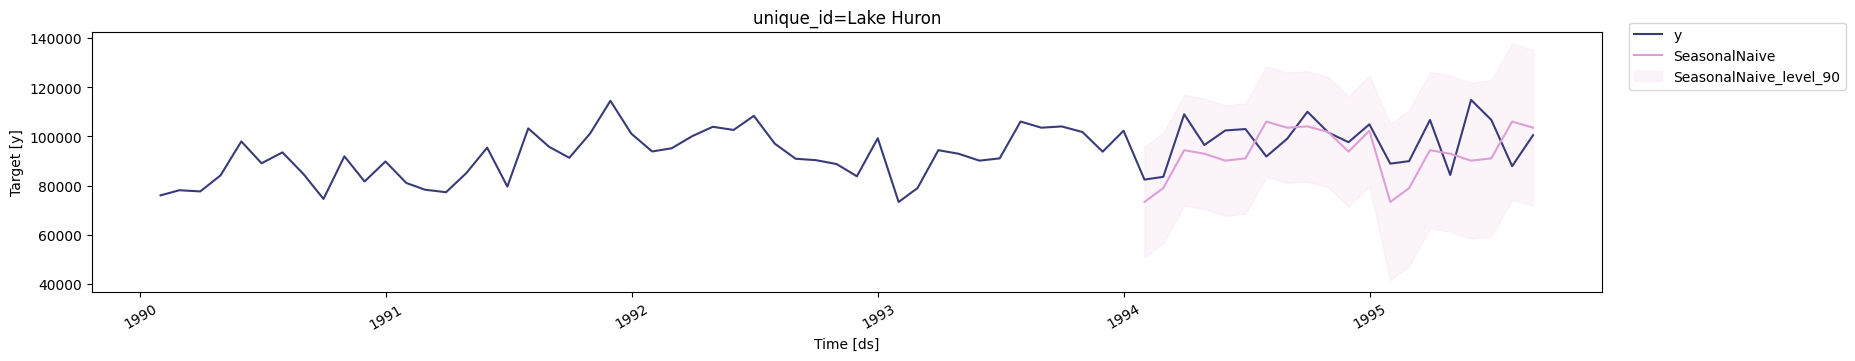

In [4]:
snaive_values = forecasts_df.SeasonalNaive.values[:20]

print(f"MASE: {mase(held_out_sample, snaive_values, y_train=y_train)}")

StatsForecast.plot(df.loc[df.ds >= pd.to_datetime("1990-01-01"), :], forecasts_df=forecasts_df,
                   models=["SeasonalNaive"], level=levels)

MASE: 0.8488993276692188


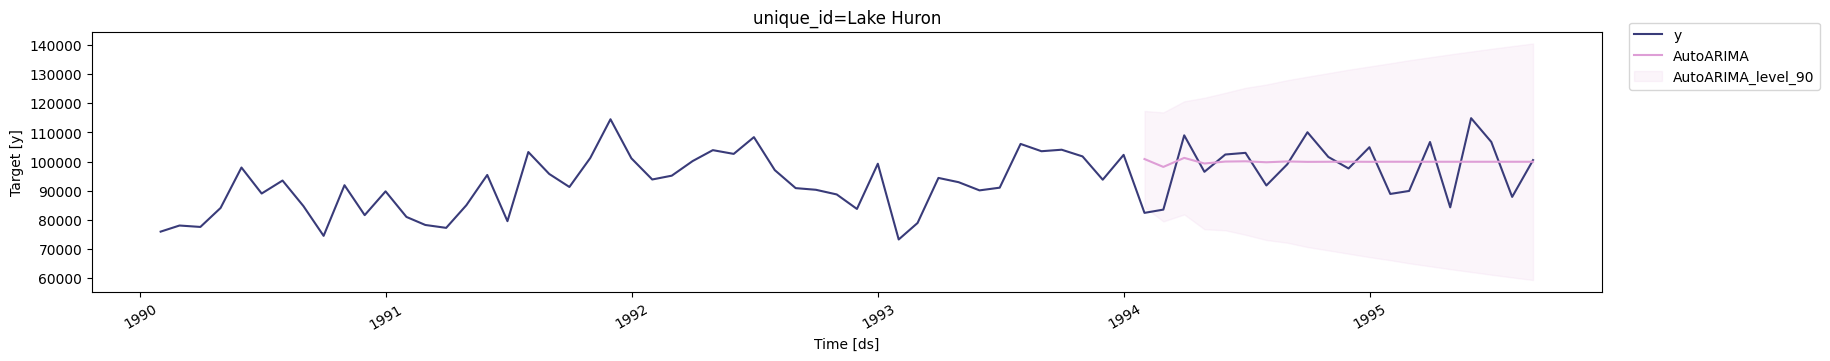

In [5]:
auto_arima_values = forecasts_df.AutoARIMA.values[:20]

print(f"MASE: {mase(held_out_sample, auto_arima_values, y_train=y_train)}")

StatsForecast.plot(df.loc[df.ds >= pd.to_datetime("1990-01-01"), :], forecasts_df=forecasts_df, models=["AutoARIMA"],
                   level=levels)

MASE: 0.8651979367559116


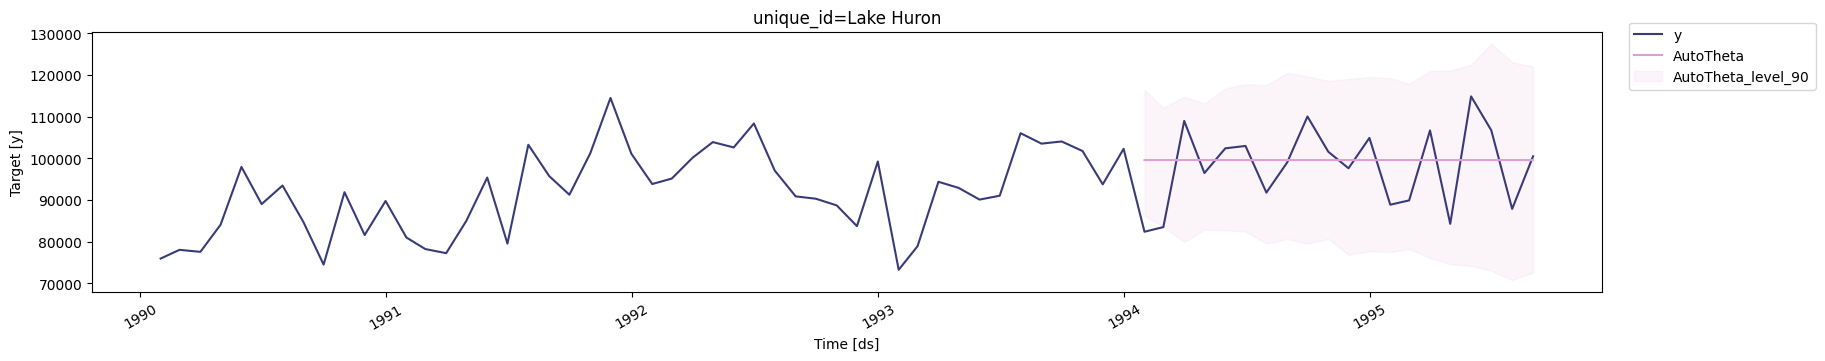

In [6]:
auto_theta_values = forecasts_df.AutoTheta.values[:20]

print(f"MASE: {mase(held_out_sample, auto_theta_values, y_train=y_train)}")

StatsForecast.plot(df.loc[df.ds >= pd.to_datetime("1990-01-01"), :], forecasts_df=forecasts_df, models=["AutoTheta"],
                   level=levels)

MASE: 0.8632762582771244


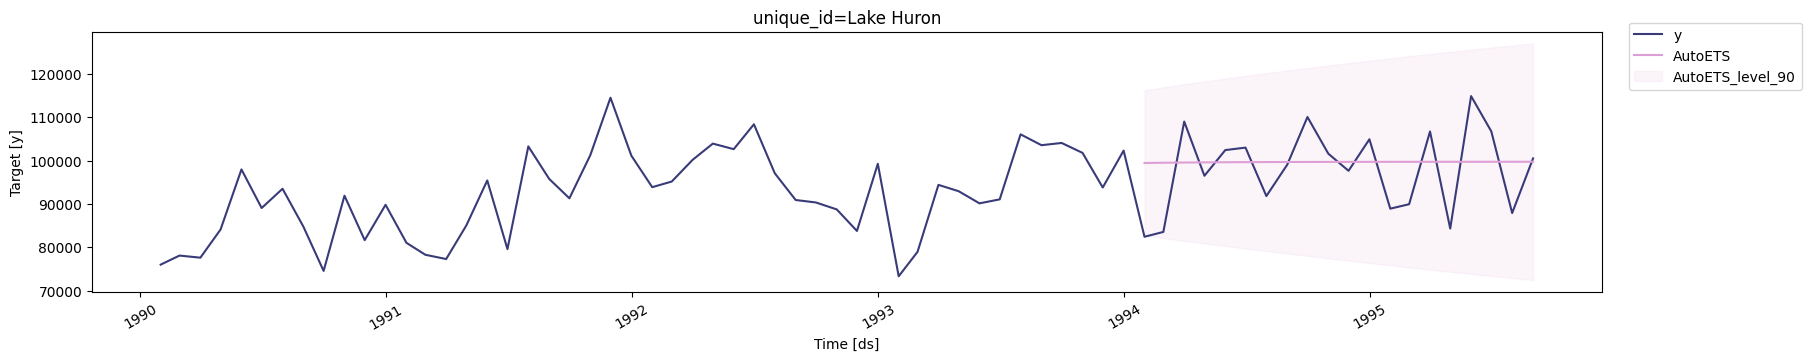

In [7]:
auto_ets_values = forecasts_df.AutoETS.values[:20]

print(f"MASE: {mase(held_out_sample, auto_ets_values, y_train=y_train)}")

StatsForecast.plot(df.loc[df.ds >= pd.to_datetime("1990-01-01"), :], forecasts_df=forecasts_df, models=["AutoETS"],
                   level=levels)

In [8]:
from chronos import BaseChronosPipeline, Chronos2Pipeline

# Load the Chronos-2 pipeline
# GPU recommended for faster inference, but CPU is also supported using device_map="cpu"
pipeline: Chronos2Pipeline = BaseChronosPipeline.from_pretrained("amazon/chronos-2", device_map="cpu")

In [9]:
input_df = df.rename(columns={"y": "value", "ds": "timestamp", "unique_id": "id"})

pred_df = pipeline.predict_df(
    input_df[input_df.timestamp < pd.to_datetime("1994-01-01")],
    prediction_length=20,
    quantile_levels=[0.05, 0.5, 0.95],
    id_column="id",
    timestamp_column="timestamp",
    target="value",
).drop(columns=["predictions"]).rename(
    columns={"id": "unique_id", "timestamp": "ds", "0.5": "Chronos2", "0.05": "Chronos2-lo-90",
             "0.95": "Chronos2-hi-90"})
pred_df

,unique_id,ds,target_name,Chronos2-lo-90,Chronos2,Chronos2-hi-90
0,Lake Huron,1994-01-31,value,77213.953125,87887.171875,99719.765625
1,Lake Huron,1994-02-28,value,81606.093750,93345.929688,105828.835938
2,Lake Huron,1994-03-31,value,87635.210938,100411.640625,113173.843750
3,Lake Huron,1994-04-30,value,81670.117188,94683.031250,108157.289062
4,Lake Huron,1994-05-31,value,86168.484375,99634.234375,113376.476562
5,Lake Huron,1994-06-30,value,86053.804688,99407.835938,113379.625000
6,Lake Huron,1994-07-31,value,87550.953125,101586.578125,115828.648438
7,Lake Huron,1994-08-31,value,86180.148438,100641.750000,115523.507812
8,Lake Huron,1994-09-30,value,83626.921875,98623.179688,113761.359375
9,Lake Huron,1994-10-31,value,82238.296875,97850.343750,113465.359375


MASE: 0.655228536473402


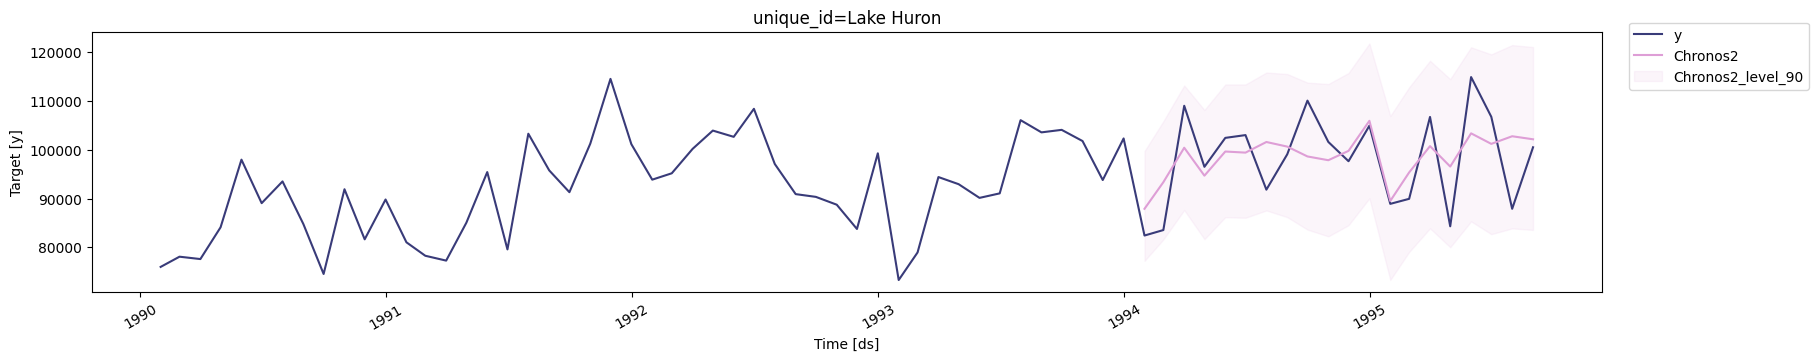

In [10]:
chronos2_values = pred_df.Chronos2.values[:20]

print(f"MASE: {mase(held_out_sample, chronos2_values, y_train=y_train)}")

StatsForecast.plot(df.loc[df.ds >= pd.to_datetime("1990-01-01"), :], forecasts_df=pred_df, models=["Chronos2"], level=levels)